In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 3})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_32680\1827036112.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [3]:
path = r"C:\Data\Imaging\260425_overlap\All_behavior//"
all_df = []
paths = fishlist = [
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for fish in paths:
    saccade_df = pd.read_csv( fish + '//eye//eye_saccade_df_classified.csv', index_col=0)
    saccade_df.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
    all_df.append(saccade_df)
all_df = pd.concat(all_df).reset_index(drop = True)

In [4]:

stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
stimorder = ['forward', 'backward', 'left', 'right', 'dot_l', 'dot_r',
                     str(['dot_l', 'forward']), str(['dot_l', 'backward']), str(['dot_l', 'left']), str(['dot_l', 'right']),
                     str(['dot_r', 'forward']), str(['dot_r', 'backward']), str(['dot_r', 'left']), str(['dot_r', 'right']),]


plotting 2p setup dot position
plotting 2p setup dot position


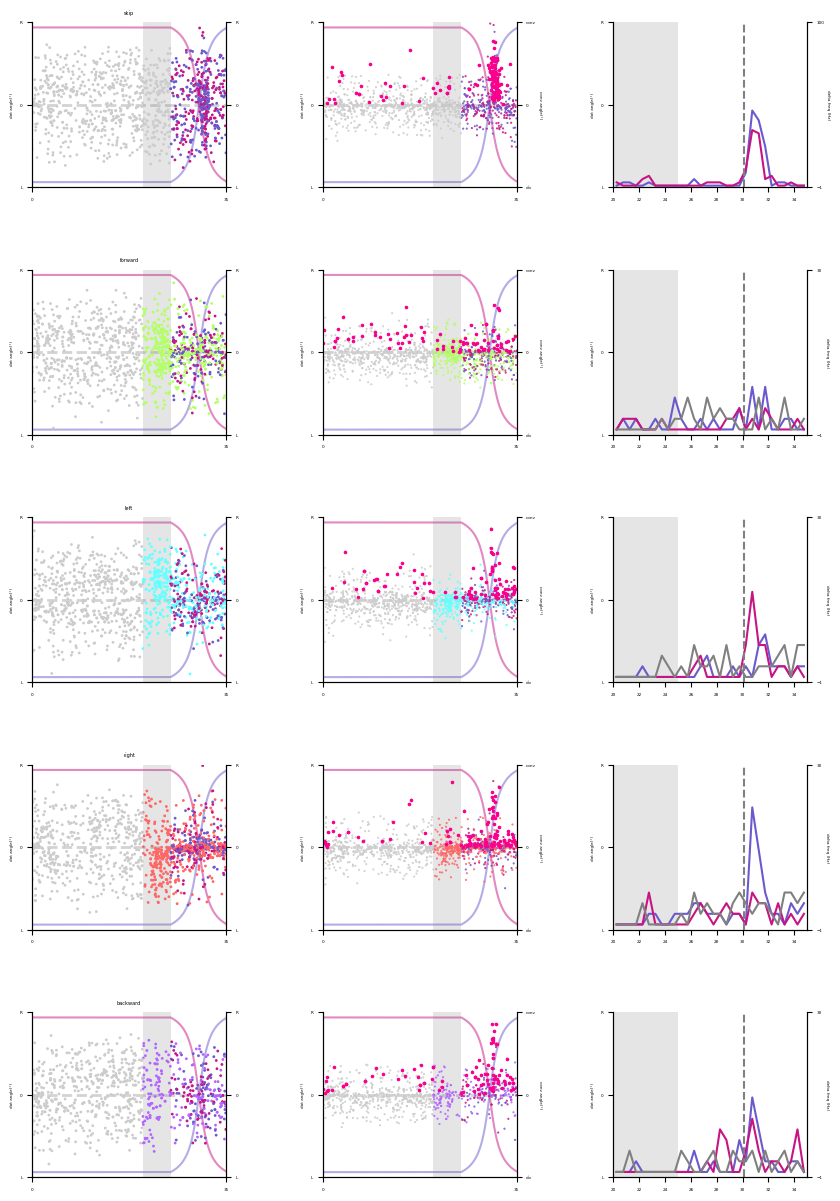

In [5]:
#plot changing eyes across time
stim_path = r"C:\Data\Imaging\260415_overlap\overlap_stim_260415.hdf"
stimulus_df = pd.read_hdf(stim_path, dtype=object).reset_index(drop=True)

# make stimulus file stationary friendly
for n, row in stimulus_df.iterrows():
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][1]:  # actual dot only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][0]
        stimulus_df.loc[n, 'angle'] = row['angle'][0]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][0]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][0]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][0]]
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][0]:  # actual grating only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][1]
        stimulus_df.loc[n, 'angle'] = row['angle'][1]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][1]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][1]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][1]]
stimulus_df.stim_name = [str(i) for i in stimulus_df.stim_name]

def plot_individual_saccade_overtime(all_df, stim_matrix, stims):
    fig, ax = plt.subplots(len(stim_matrix), 3, figsize = (10, 15), gridspec_kw = {'wspace': 0.5, 'hspace': 0.5})
    for n, row in enumerate(stim_matrix):
        for stim in row:
            if stim =='skip' or stim == 'pause':
                continue
            if 'dot_l' in stim:
                stimc = 'slateblue'
            elif 'dot_r' in stim:
                stimc = 'mediumvioletred'
            elif stim in utils.omr_angles.keys():
                stimc = utils.stim_colors[stim]
            # elif 'pause' in stim:
            #     stimc = 'grey'
            stim_df = stims[stims['stim_name'] == stim].iloc[0]
            _, stim_loc_timescale, stim_loc_scale, center_time= utils.get_dot_pos(stim_df, canvas_size=1024)
            #because it's behavior rig, stim_loc_scale got changed
            #stim_loc_scale = np.subtract(0, stim_loc_scale)
            [ax[n, col].plot(stim_loc_timescale, stim_loc_scale, c = stimc, alpha = 0.5, zorder = 0) for col in range(2)]
        row_saccade_df = all_df.loc[all_df['eye_stimuli'].isin(row)]
        stim_c = ['grey' if 'pause' in s else 'slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else utils.stim_colors[s] for s in row_saccade_df.eye_realstimuli]#['slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else 'grey' for s in row_saccade_df.eye_realstimuli]
        ax_conj = ax[n,0].twinx()
        ax_conj.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conj_change, color = stim_c, s = 1, zorder = 2)
        ax_conv = ax[n,1].twinx()
        ax_conv.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conv_change, color = stim_c, marker = '.', s = 1, zorder = 2)
        row_conv = row_saccade_df[row_saccade_df.saccade_type == 'H']
        stim_c = ['grey' if 'pause' in s else 'slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else utils.stim_colors[s] for s in row_conv.eye_realstimuli]
        ax_conv.scatter(row_conv.eye_fromstart_s, row_conv.e_conv_change, color = utils.pink,marker = '.',  s = 10, zorder = 2)
        ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
        ax[n, 0].set_ylabel('dot angle(°)')
        ax_conj.yaxis.set_label_position("right")
        ax[n, 1].set_ylabel('dot angle(°)')
        ax_conv.yaxis.set_label_position("right")
        ax_conv.set_ylabel('conv angle(°)', rotation = 270)
        [ax[n, col].axhline(0, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1)  for col in range(2)]
        [ax[n, col].set_xlim([0, 35]) for col in range(2)]
        [ax[n, col].set_xticks([0, 35]) for col in range(2)]
        [ax[n, col].set_ylim([-80, 80]) for col in range(2)]
        [ax[n, col].set_yticks([-80,0, 80]) for col in range(2)]
        [ax[n, col].set_yticklabels(['L', 0, 'R']) for col in range(2)]
        ax_conj.set_ylim([-70, 70])
        ax_conj.set_yticks([-70,0, 70])
        ax_conj.set_yticklabels(['L', 0, 'R'])
        lim = 60
        ax_conv.set_ylim([-lim, lim])
        ax_conv.set_yticks([-lim,0, lim])
        ax_conv.set_yticklabels(['div', 0, 'conv'])
        [ax[n, col].spines[['top']].set_visible(False) for col in range(2)]
        ax_conv.spines[['top']].set_visible(False)
        ax_conj.spines[['top']].set_visible(False)

        #plot frequency over time
        ax_freq = ax[n,2].twinx()
        dotl_stims = [s for s in row if 'dot_l' in s]
        dotr_stims = [s for s in row if 'dot_r' in s]
        nondot_stims = [s for s in row if 'dot' not in s]
        timebin_s = .5
        baseline_s = 25
        row_saccade_dotl_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(dotl_stims)]
        row_saccade_dotr_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(dotr_stims)]
        row_saccade_nondot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(nondot_stims)]
        for row_df, color in zip([row_saccade_dotl_df, row_saccade_dotr_df, row_saccade_nondot_df], [utils.stim_colors['dot_l'], utils.stim_colors['dot_r'], 'grey']):
            if len(row_df) > 0:
                freqs = []
                for fish in row_df.real_fish_id.unique():
                    df = row_df[(row_df.eye_fromstart_s >=20) &(row_df.real_fish_id == fish)]
                    df_conv = df[df.saccade_type == 'H']
                    count_conv, bin_loc = np.histogram(df_conv.eye_fromstart_s, bins = int(15//timebin_s), range = [20, 35])
                    freq = np.divide(count_conv, timebin_s)
                    freqs.append(freq)
                bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
                mean = np.nanmean(freqs, axis = 0)
                std = np.nanstd(freqs, axis = 0)
                sem = np.divide(std, np.sqrt(len(freqs)))
                ax_freq.plot(bin_center, mean, color = color, zorder = 1)
                ax_freq.fill_between(bin_center, mean - sem, mean + sem, color = color, zorder = 1, linewidth = 0, alpha = 0.25)
        ax_freq.spines[['top']].set_visible(False)
        ax[n,2].spines[['top']].set_visible(False)
        [ax[n, i].axvspan(20, baseline_s, alpha = 0.2, linewidth = 0, color = 'grey') for i in range(3)]
        ax[n, 2].set_xlim([20, 35])
        ax_freq.set_xlim([20, 35])
        ax[n, 2].set_ylim([-100, 10])
        ax[n, 2].set_yticks([-100,0, 100])
        ax[n, 2].set_yticklabels(['L', 0, 'R'])
        if n == 0:
            ax_freq.set_ylim([-1, 100])
            ax_freq.set_yticks([-1, 100])
        else:
            ax_freq.set_ylim([-1, 30])
            ax_freq.set_yticks([-1, 30])
        ax_freq.axvline(center_time, linestyle = '--', color = 'grey')
        ax[n, 2].set_ylabel('dot angle(°)')
        ax_freq.set_ylabel('delta freq (Hz)', rotation = -90)
    return fig

#stim_matrix = [['dot_l'], ['dot_r']]
fig = plot_individual_saccade_overtime(all_df, stim_matrix, stimulus_df)
fig.savefig(path + r"saccade_acrosstime_classified.svg")
plt.show()
plt.close()

forward
backward
left
right
dot_l
plotting 2p setup dot position
dot_r
plotting 2p setup dot position
['dot_l', 'forward']
['dot_l', 'backward']
['dot_l', 'left']


C:\Users\Zichen\AppData\Local\Temp\ipykernel_32680\21011957.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
C:\Users\Zichen\AppData\Local\Temp\ipykernel_32680\21011957.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
C:\Users\Zichen\AppData\Local\Temp\ipykernel_32680\21011957.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[

['dot_l', 'right']
['dot_r', 'forward']
['dot_r', 'backward']
['dot_r', 'left']
['dot_r', 'right']


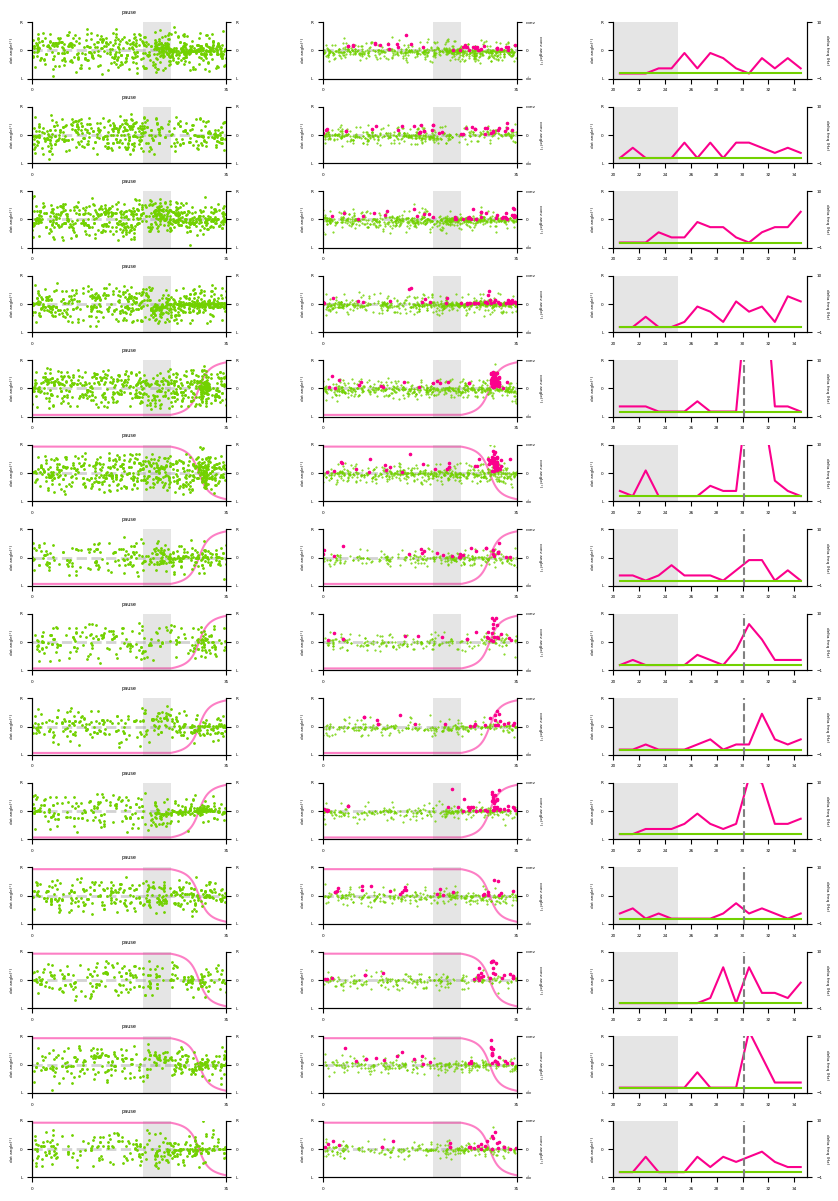

In [6]:
def plot_individual_saccade_overtime2(all_df, stim_order, stims):
    fig, ax = plt.subplots(len(stim_order), 3, figsize = (10, 15), gridspec_kw = {'wspace': 0.5, 'hspace': 0.5})
    for n, stim in enumerate(stim_order):
        print(stim)
        stim_df = stims[stims['stim_name'] == stim].iloc[0]
        if 'dot' in stim:
            _, stim_loc_timescale, stim_loc_scale, center_time= utils.get_dot_pos(stim_df, canvas_size=1024)
            #because it's behavior rig, stim_loc_scale got changed
            #stim_loc_scale = np.subtract(0, stim_loc_scale)
            [ax[n, col].plot(stim_loc_timescale, stim_loc_scale, c = utils.pink, alpha = 0.5, zorder = 0) for col in range(2)]
        row_saccade_df = all_df.loc[all_df['eye_stimuli'] == stim]
        ax_conj = ax[n,0].twinx()
        ax_conj.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conj_change, color = utils.green, s = 1, zorder = 2)
        ax_conv = ax[n,1].twinx()
        ax_conv.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conv_change, color = utils.green, marker = '.', s = 1, zorder = 2)
        row_conv = row_saccade_df[row_saccade_df.saccade_type == 'H']
        ax_conv.scatter(row_conv.eye_fromstart_s, row_conv.e_conv_change, color = utils.pink,marker = '.',  s = 10, zorder = 2)
        ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
        ax[n, 0].set_ylabel('dot angle(°)')
        ax_conj.yaxis.set_label_position("right")
        ax[n, 1].set_ylabel('dot angle(°)')
        ax_conv.yaxis.set_label_position("right")
        ax_conv.set_ylabel('conv angle(°)', rotation = 270)
        [ax[n, col].axhline(0, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1)  for col in range(2)]
        [ax[n, col].set_xlim([0, 35]) for col in range(2)]
        [ax[n, col].set_xticks([0, 35]) for col in range(2)]
        [ax[n, col].set_ylim([-80, 80]) for col in range(2)]
        [ax[n, col].set_yticks([-80,0, 80]) for col in range(2)]
        [ax[n, col].set_yticklabels(['L', 0, 'R']) for col in range(2)]
        ax_conj.set_ylim([-70, 70])
        ax_conj.set_yticks([-70,0, 70])
        ax_conj.set_yticklabels(['L', 0, 'R'])
        lim = 60
        ax_conv.set_ylim([-lim, lim])
        ax_conv.set_yticks([-lim,0, lim])
        ax_conv.set_yticklabels(['div', 0, 'conv'])
        [ax[n, col].spines[['top']].set_visible(False) for col in range(2)]
        ax_conv.spines[['top']].set_visible(False)
        ax_conj.spines[['top']].set_visible(False)

        #plot frequency over time
        ax_freq = ax[n,2].twinx()
        timebin_s = 1
        baseline_s = 25
        row_nonconv = row_saccade_df[row_saccade_df['saccade_type'] != 'H']
        for row_df, color in zip([row_conv, row_nonconv], [utils.pink, utils.green]):
            if len(row_df) > 0:
                freqs = []
                for fish in row_df.real_fish_id.unique():
                    df = row_df[(row_df.eye_fromstart_s >=20) &(row_df.real_fish_id == fish)]
                    df_conv = df[df.saccade_type == 'H']
                    count_conv, bin_loc = np.histogram(df_conv.eye_fromstart_s, bins = int(15//timebin_s), range = [20, 35])
                    freq = np.divide(count_conv, timebin_s)
                    freqs.append(freq)
                bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
                mean = np.nanmean(freqs, axis = 0)
                std = np.nanstd(freqs, axis = 0)
                sem = np.divide(std, np.sqrt(len(freqs)))
                ax_freq.plot(bin_center, mean, color = color, zorder = 1)
                ax_freq.fill_between(bin_center, mean - sem, mean + sem, color = color, zorder = 1, linewidth = 0, alpha = 0.25)
        ax_freq.spines[['top']].set_visible(False)
        ax[n,2].spines[['top']].set_visible(False)
        [ax[n, i].axvspan(20, baseline_s, alpha = 0.2, linewidth = 0, color = 'grey') for i in range(3)]
        ax[n, 2].set_xlim([20, 35])
        ax_freq.set_xlim([20, 35])
        ax[n, 2].set_ylim([-100, 10])
        ax[n, 2].set_yticks([-100,0, 100])
        ax[n, 2].set_yticklabels(['L', 0, 'R'])
        ax_freq.set_ylim([-1, 10])
        ax_freq.set_yticks([-1, 10])
        if 'dot' in stim:
            ax_freq.axvline(center_time, linestyle = '--', color = 'grey')
        ax[n, 2].set_ylabel('dot angle(°)')
        ax_freq.set_ylabel('delta freq (Hz)', rotation = -90)
    return fig

fig = plot_individual_saccade_overtime2(all_df, stimorder, stimulus_df)
fig.savefig(path + r"saccade_acrosstime_classified.svg")
plt.show()
plt.close()

plotting 2p setup dot position


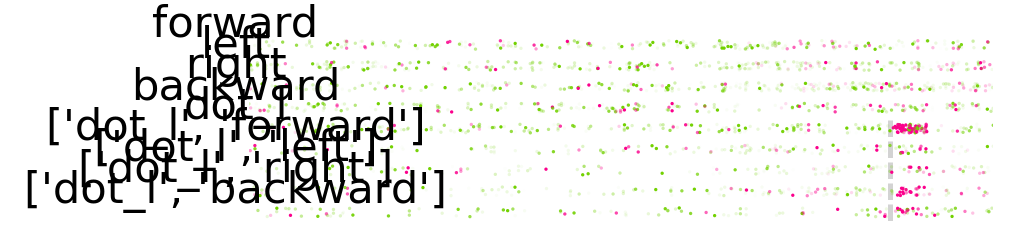

plotting 2p setup dot position


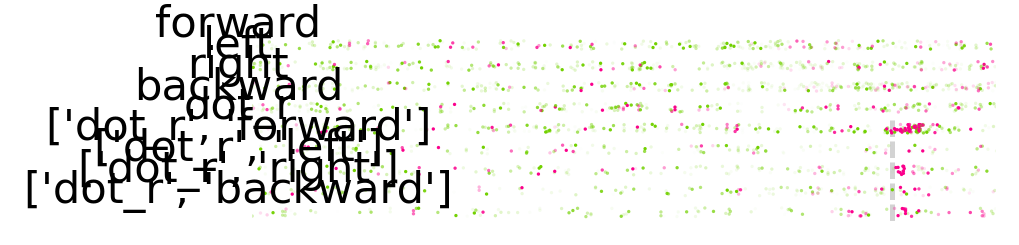

plotting 2p setup dot position


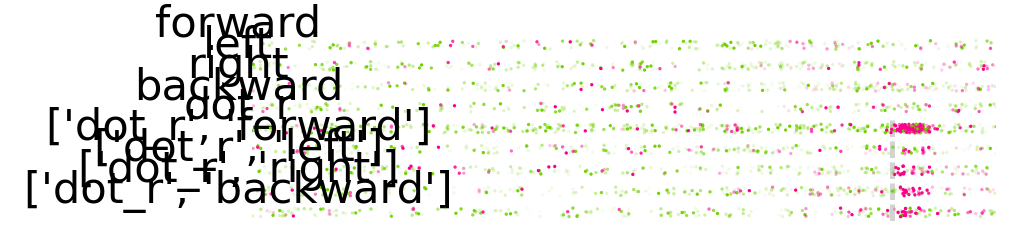

In [9]:
stim_list = ['forward', 'left', 'right', 'backward', 'dot_l', str(['dot_l', 'forward']), str(['dot_l', 'left']),
             str(['dot_l', 'right']), str(['dot_l', 'backward'])]
bhfd.plot_simplesaccade(all_df, stim_list, 'slateblue', stimulus_df, classified= True)
plt.savefig(path + 'simple_saccade_dotl.svg')
plt.show()
plt.close()

stim_list = ['forward', 'left', 'right', 'backward', 'dot_r', str(['dot_r', 'forward']), str(['dot_r', 'left']),
             str(['dot_r', 'right']), str(['dot_r', 'backward'])]
bhfd.plot_simplesaccade(all_df, stim_list, 'mediumvioletred', stimulus_df, classified=True)
plt.savefig(path + 'simple_saccade_dotr.svg')
plt.show()
plt.close()

#new graph
stim_lists = [['forward'], ['left'], ['right'], ['backward'],
              ['dot_l', 'dot_r'],
              [str(['dot_l', 'forward']), str(['dot_r', 'forward'])],
              [str(['dot_l', 'left']), str(['dot_r', 'left'])],
              [str(['dot_l', 'right']), str(['dot_r', 'right'])],
              [str(['dot_l', 'backward']), str(['dot_r', 'backward'])]
              ]
bhfd.plot_simpleeyecombine(all_df, stim_lists, stimulus_df, classified=True)
plt.savefig(path + 'simple_saccade_dots.svg')
plt.show()
plt.close()